# Tracing every paper number to saved results — iteration-5 audit (demo)

This notebook is a readable, runnable version of **`eval.py`**, the orchestrator of an *analysis-only* audit for the
study *"Does Slovene-taught refusal survive?"* (GaMS3-12B-Instruct vs Gemma-3-12B-it). The audit made **no paid calls
($0 OpenRouter)**. Its decision rules were frozen in `protocol_eval.yaml` before any computation, so these post-hoc
analyses can **downgrade** a claim but can never confirm one.

`eval.py` does two things:

1. **Steps 0–7** (`--skip-steps` turns them off) call the modules in `src/`: `check_inputs`, `ceiling`,
   `kl_excess`, `decomposition`, `exp14_tables`, `ledger`, `owed`, then `verify/verify.py`, then `make_tables`.
   These steps read many **read-only upstream artifacts** (exp4–exp15 rows, judge labels, the iteration-4 paper
   draft). Those files are not published with this demo, so the notebook runs the script's `--skip-steps` path.
2. **`build_eval_out()`** reads the saved `results/*.json` of those steps and assembles `eval_out.json`:
   * `metrics_agg`: the headline numbers (ceiling fragility of exp15 `G3_orig`, C5a KL-excess verdicts,
     decomposition status counts, exp14 table cross-check, correction-ledger counts, criterion-shift harmonisation,
     exp13 overlap, verification pass rate);
   * `datasets`: one example per audited paper number, ceiling row, KL row and decomposition row.

**What the demo data holds.** `mini_demo_data.json` contains the seven results files that `build_eval_out()` reads.
One file is subsampled: the correction ledger keeps all 22 hand-written pointers plus a **stratified sample of 56 of
its 1,176 auto-matched tokens**. The ledger *counts* (`ledger_tokens`, `ledger_survives`, …) are the saved values for
the full ledger, so every `metrics_agg` number can be checked **exactly** against the saved `full_eval_out.json`,
which is bundled as `reference_metrics_agg`. Only the size of the ledger example list is smaller.

**Key findings the numbers encode** (see the summary at the end):
* exp15's baseline offset `G3_orig = -1.171` is a **CEILING-ARTEFACT**: one flipped Gemma label moves it inside ±m (FI_m = 1).
* C5a "no Slovene leakage" holds only in some bodies: **8 of 12** KL rows are NO-LEAKAGE and **4** are UNDETERMINED.
* **15 of 107** decomposition rows are edit-induced and **0** are baseline; the rest are underdetermined.
* The exp14 tables regenerate with **0 mismatches**, and the independent verifier passes **49/49** checks.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT pre-installed on Colab, always install (same pin as the artifact's pyproject.toml)
_pip('loguru==0.7.3')

# numpy, matplotlib — pre-installed on Colab, install locally only (at Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')

## Imports

This is the original import block of `eval.py`. The script also imports its own step modules from `src/` (`ceiling`,
`check_inputs`, `decomposition`, `exp14_tables`, `kl_excess`, `ledger`, `make_tables`, `owed`, `common`). Those
modules need the upstream artifacts, so their imports are commented out here. The few helpers `build_eval_out()` uses
from `common` (`RES`, `read_json`, `rel`, `setup_logging`) are redefined two cells below to read from the loaded data.
`numpy` and `matplotlib` are added for the final visualization only.

In [2]:
from __future__ import annotations

import argparse
import json
import resource
import subprocess
import sys
from pathlib import Path

WS = Path.cwd()  # original: Path(__file__).resolve().parent  (a notebook has no __file__)
# sys.path.insert(0, str(WS / "src"))

from loguru import logger  # noqa: E402

# Step modules of the full pipeline: they read the read-only upstream artifacts, which are not part of this demo.
# import ceiling  # noqa: E402
# import check_inputs  # noqa: E402
# import decomposition  # noqa: E402
# import exp14_tables  # noqa: E402
# import kl_excess  # noqa: E402
# import ledger  # noqa: E402
# import make_tables  # noqa: E402
# import owed  # noqa: E402
# from common import RES, read_json, rel, setup_logging  # noqa: E402

# --- added for the notebook's visualization cell
import numpy as np
import matplotlib.pyplot as plt

## Data loading

The data comes from the GitHub raw URL. If that fails (for example before the repository is published), the local `mini_demo_data.json` is used instead.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-2cf2a7-does-slovene-taught-refusal-survive/fork/run_6GCdZCQAemW2/round-5/evaluation-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["about"])
print("results files:", list(data["results"]))

Inputs of eval.py build_eval_out() (iteration-5 audit results/*.json). correction_ledger.json rows are a stratified sample of 56 of 1176 rows (all 22 pointers kept); exp14_tables_regenerated.json is reduced to the keys build_eval_out reads plus sdt_DiD.
results files: ['ceiling_sensitivity.json', 'kl_excess.json', 'decomposition_table.json', 'correction_ledger.json', 'step6.json', 'verify.json', 'exp14_tables_regenerated.json']


## Configuration

`eval.py` has no training-style hyper-parameters. Everything it does is deterministic bookkeeping over saved
results. Its tunable knobs are listed here:

* `SKIP_STEPS` stands in for the `--skip-steps` CLI flag. It must stay `True` in the demo. `False` would re-run
  Steps 0–7, which need the upstream artifacts and the `src/` modules of the full repository. The original default
  was `False`.
* `MAX_LEDGER_ROWS` is how many of the bundled correction-ledger token rows turn into `datasets` examples. The mini
  data holds 56 (the full ledger has 1,176). The pointers and the `metrics_agg` counts are not affected.
* `RLIMIT_AS_GB` is the address-space cap the original script sets (60 GB, sized for the full `rows_final` +
  readout frame).

In [5]:
SKIP_STEPS = True        # original CLI default: False (runs Steps 0-7; needs the upstream artifacts)
MAX_LEDGER_ROWS = 56     # all 56 bundled ledger rows (full ledger: 1176 rows; the full run uses all of them)
RLIMIT_AS_GB = 60        # original: 60 GB

## Shared helpers from `src/common.py`, adapted to the loaded data

In the original, `read_json(RES / "x.json")` opens `results/x.json` on disk. Here `read_json` returns the same
object from `data["results"]`, keyed by file name, so the body of `build_eval_out()` below stays **unchanged**.
`rel()` and `setup_logging()` keep their original behaviour, except that logging goes to stdout only (the original
also wrote `logs/<name>.log`). `MAX_LEDGER_ROWS` is applied here as well.

In [6]:
import copy

RES = WS / "results"


def read_json(p: Path):
    # original: json.loads(Path(p).read_text())
    obj = copy.deepcopy(data["results"][Path(p).name])
    if Path(p).name == "correction_ledger.json":
        obj["rows"] = obj["rows"][:MAX_LEDGER_ROWS]
    return obj


def rel(p: Path | str) -> str:
    # Run-relative path for provenance (no absolute server paths in published files).
    p = Path(p)
    try:
        return str(p.relative_to(WS))
    except ValueError:
        return str(p)


def setup_logging(name: str) -> None:
    logger.remove()
    logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|" + name + "|{message}")

## Resource limit, status codes and formatting helpers (verbatim)

The ledger gives every audited paper number a status, following the frozen `ledger_status` rules in `protocol_eval.yaml`:
* **SURVIVES**: equal within half a unit of the last shown digit, verdict unchanged;
* **SHRINKS**: same sign but smaller beyond rounding, or the CI now includes 0;
* **REVERSES**: the sign or the verdict flips;
* **UNTRACEABLE**: no saved file holds the number. This is the default, and numbers are never force-matched.

`STATUS_CODE` maps these statuses to numbers for the `eval_status_code` field. `s()` formats values and CIs as text.

In [7]:
resource.setrlimit(resource.RLIMIT_AS, (RLIMIT_AS_GB * 1024 ** 3, RLIMIT_AS_GB * 1024 ** 3))  # rows_final + readout frame fit well below this

STATUS_CODE = {"SURVIVES": 1.0, "SHRINKS": 2.0, "REVERSES": 3.0, "UNTRACEABLE": 0.0}


def fnum(x):
    return None if x is None else float(x)


def s(x, nd=4):
    if x is None:
        return "NA"
    if isinstance(x, (list, tuple)):
        return "[" + ", ".join(s(v, nd) for v in x) + "]"
    return f"{x:.{nd}f}" if isinstance(x, float) else str(x)

## `build_eval_out()`: assemble headline metrics and per-row examples (verbatim)

This function is the core of `eval.py`, copied without changes. It reads seven results files:

| file | what it holds |
|---|---|
| `ceiling_sensitivity.json` | exp15 λ=0 counts (Gemma 294/299, GaMS3 289/292 of 300), `G3_orig` (Hautus log-linear logits), fragility indices FI_m / FI_0, four alternative estimators, the probability-scale DiD bootstrap, the Jeffreys posterior, the model-label permutation test, judge-error expectations, and the same ceiling check across the eval3 bodies and readouts |
| `kl_excess.json` | C5a excess ratio `[KL_E(SL)/KL_E(EN)] / [KL_R(SL)/KL_R(EN)]` per body × model, with bootstrap CIs and verdicts (LEAKAGE / NO-LEAKAGE / UNDETERMINED / POINT-ONLY) |
| `decomposition_table.json` | 107 body × readout rows splitting G3 into `G3_orig` + `G3_edit`, each labelled edit-induced / baseline / underdetermined |
| `correction_ledger.json` | every number in the iteration-4 paper draft, traced to a saved JSON leaf (22 pointers + auto-matched tokens) |
| `step6.json` | criterion-shift harmonisation (sign-aligned so that negative = Gemma shifts toward refusing in Slovene), exp13 overlap record, coverage and verdict tables |
| `verify.json` | the independent re-implementation's 49 checks |
| `exp14_tables_regenerated.json` | cross-check of the regenerated exp14 tables against `rows_final` and against the draft's Tables 28–29 |

In [8]:
def build_eval_out() -> dict:
    c, k, d = read_json(RES / "ceiling_sensitivity.json"), read_json(RES / "kl_excess.json"), read_json(RES / "decomposition_table.json")
    lg, s6, v = read_json(RES / "correction_ledger.json"), read_json(RES / "step6.json"), read_json(RES / "verify.json")
    e14 = read_json(RES / "exp14_tables_regenerated.json")
    fi = c["fragility_index"]
    pu = c["judge_error"].get("pooled_unedited", {})
    ma = {
        "exp15_G3_orig": c["smoke"]["G3_orig"], "exp15_FI_m": fi["FI_m"], "exp15_FI_0": fi["FI_0"],
        "exp15_prob_did_pp": c["estimators"]["point"]["vi_probability_scale_pp"],
        "exp15_prob_did_pp_ci95_lo": c["bootstrap"]["prob_did_pp"]["ci95"][0], "exp15_prob_did_pp_ci95_hi": c["bootstrap"]["prob_did_pp"]["ci95"][1],
        "exp15_G3_orig_boot_ci95_lo": c["bootstrap"]["hautus"]["ci95"][0], "exp15_G3_orig_boot_ci95_hi": c["bootstrap"]["hautus"]["ci95"][1],
        "exp15_jeffreys_P_G3orig_lt_minus_m": c["estimators"]["jeffreys_posterior"]["P_lt_minus_m"],
        "exp15_jeffreys_P_G3orig_lt_0": c["estimators"]["jeffreys_posterior"]["P_lt_0"],
        "exp15_estimator_min": min(c["estimators"]["point"][x] for x in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit")),
        "exp15_estimator_max": max(c["estimators"]["point"][x] for x in ("i_hautus_loglinear", "ii_laplace_add1", "iii_half_n_rule_extreme_cells_only", "iv_jeffreys_posterior_mean_of_logit")),
        "exp15_gemma_mcnemar_p": c["paired_exact"]["gemma_it"]["mcnemar_exact_p"],
        "exp15_model_perm_p": c["permutation_model_label"]["p_two_sided"],
        "exp15_leave1_max": c["leave_k_items"]["1"]["max"], "exp15_leave3_worst_case": c["leave_k_items"]["3"]["worst_case_remove_gemma_discordant_b"],
        "exp15_expected_mislabels_4cells": pu.get("expected_mislabels_total_4cells", -1),
        "exp15_ceiling_artefact": float(c["verdict"] == "CEILING-ARTEFACT"),
        "kl_exp15_gemma_excess": k["exp15"]["gemma_it"]["point_excess_top_dose"], "kl_exp15_gams_excess": k["exp15"]["gams3_it"]["point_excess_top_dose"],
        "kl_exp14_gemma_excess": k["exp14"]["gemma_it"]["mean"]["point"], "kl_exp14_gemma_ci95_lo": k["exp14"]["gemma_it"]["mean"]["ci95_pct"][0],
        "kl_exp14_gemma_ci95_hi": k["exp14"]["gemma_it"]["mean"]["ci95_pct"][1],
        "kl_exp14_gams_excess": k["exp14"]["gams3_it"]["mean"]["point"], "kl_exp14_gams_ci95_hi": k["exp14"]["gams3_it"]["mean"]["ci95_pct"][1],
        "kl_exp9_gemma_excess": k["exp9"]["gemma_it"]["recomputed_point"], "kl_exp9_gams_excess": k["exp9"]["gams3_it"]["recomputed_point"],
        "kl_rows_no_leakage": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "NO-LEAKAGE"),
        "kl_rows_undetermined": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "UNDETERMINED"),
        "kl_rows_point_only": sum(1 for r in k["reconciliation"]["rows"] if r.get("verdict") == "POINT-ONLY"),
        "decomp_rows": d["n_rows"], "decomp_edit_induced": d["status_counts"]["edit-induced"],
        "decomp_baseline": d["status_counts"]["baseline"], "decomp_underdetermined": d["status_counts"]["underdetermined"],
        "exp14_crosscheck_mismatches": e14["crosscheck"]["n_mismatch"],
        "exp14_paper_tables_28_29_values_compared": e14.get("paper_table_diff", {}).get("n_cells_compared"),
        "exp14_paper_tables_28_29_values_differ": e14.get("paper_table_diff", {}).get("n_differ"),
        "crit_rows_total": len(s6["criterion_shift"]["rows"]),
        "crit_rows_invalid_manipulation": sum(1 for r in s6["criterion_shift"]["rows"] if not r.get("manipulation_valid", True)),
        "crit_valid_rows_ci_below_0": sum(1 for r in s6["criterion_shift"]["rows"] if r.get("manipulation_valid", True)
                                          and r.get("harmonised_ci95") and r["harmonised_ci95"][1] < 0),
        "crit_valid_rows_ci_above_0": sum(1 for r in s6["criterion_shift"]["rows"] if r.get("manipulation_valid", True)
                                          and r.get("harmonised_ci95") and r["harmonised_ci95"][0] > 0),
        "ledger_tokens": lg["n_tokens"], "ledger_pointers": lg["n_pointers"],
        "ledger_survives": lg["counts_by_status"].get("SURVIVES", 0), "ledger_shrinks": lg["counts_by_status"].get("SHRINKS", 0),
        "ledger_reverses": lg["counts_by_status"].get("REVERSES", 0), "ledger_untraceable": lg["counts_by_status"].get("UNTRACEABLE", 0),
        "ledger_claim_level_reversals": len(lg["claim_level_reversals"]), "ledger_attribution_errors": len(lg["attribution_errors"]),
        "ledger_placebo_auto_match_rate": lg["placebo_auto_match_rate"],
        "exp13_B_overlap": s6["exp13"]["recomputed"]["B_overlap"], "exp13_C_overlap": s6["exp13"]["recomputed"]["C_overlap"],
        "exp13_never_generated": s6["exp13"]["recomputed"]["never_generated_total"],
        "verify_pass_rate": v["pass_rate"], "verify_n_checks": v["n_checks"], "openrouter_spend_usd": 0.0,
    }
    for body, x in c["extension_eval3_bodies"].items():
        g = x.get("by_label", {}).get("gemini_raw_prim3") if isinstance(x, dict) else None
        if g:
            ma[f"eval3_{body}_G3_orig_gemini"] = g["G3_orig_hautus"]
            ma[f"eval3_{body}_FI_m_gemini"] = g["FI_m"]
    gs = k.get("gpu_recompute_gate")
    if gs:
        ma["kl_gpu_gate_pass"] = float(bool(gs.get("pass")))
    ma = {kk: float(vv) for kk, vv in ma.items() if vv is not None}

    ex_ledger = []
    for p in lg["pointers"]:
        st = p["status"].split(" ")[0]
        ex_ledger.append({
            "input": f"[paper line {p['line']}, cites {p['cited_artifact']}] {p.get('paper_sentence', '')[:600]} || audited number: {p['paper_token']}",
            "output": f"verified {s(p.get('verified_value'))} CI {s(p.get('verified_ci95'))} from {p.get('source_file')} :: {p.get('json_path')}",
            "metadata_claim_id": p["claim_id"], "metadata_match_method": "pointer", "metadata_eval_status": st,
            "metadata_claim_status": p.get("claim_status", ""), "metadata_eval_source_file": p.get("source_file") or "",
            "metadata_eval_json_path": p.get("json_path") or "", "metadata_note": p.get("note", ""),
            "predict_paper_value": p["paper_token"], "predict_verified_value": s(p.get("verified_value")),
            "eval_status_code": STATUS_CODE.get(st, 0.0), "eval_attribution_ok": 1.0 if p.get("attribution_ok") else 0.0,
            "eval_abs_diff": abs(p["paper_value"] - p["verified_value"]) if p.get("verified_value") is not None else -1.0})
    for r in lg["rows"]:
        ex_ledger.append({
            "input": f"[paper line {r['line']}, section '{r['section'][:80]}', cites {r['cited_artifact']}] {r['sentence'][:500]} || audited number: {r['token']}",
            "output": (f"verified {s(r.get('verified_value'))} from {r.get('source_file')} :: {r.get('json_path')}" if r.get("verified_value") is not None
                       else f"UNTRACEABLE ({r['match_method']}; {r.get('n_candidates', 0)} candidate leaves)"),
            "metadata_claim_id": r["claim_id"], "metadata_match_method": r["match_method"], "metadata_eval_status": r["status"],
            "metadata_eval_source_file": r.get("source_file") or "", "metadata_eval_json_path": r.get("json_path") or "",
            "metadata_token_kind": r["kind"], "metadata_superseded_by_pointer": r.get("superseded_by_pointer", ""),
            "predict_paper_value": r["token"], "predict_verified_value": s(r.get("verified_value")),
            "eval_status_code": STATUS_CODE.get(r["status"], 0.0),
            "eval_attribution_ok": 1.0 if r.get("attribution_ok") else 0.0,
            "eval_n_candidates": float(r.get("n_candidates", 0))})
    ex_ceiling = [{
        "input": f"exp15 lambda-0 G3_orig (J1 raw): counts {c['smoke']['counts_rows_final']} of {c['smoke']['n_rows_final']}",
        "output": c["paper_sentence"], "metadata_body": "exp15_ladder", "metadata_label": "J1 raw (local)", "metadata_verdict": c["verdict"],
        "predict_G3_orig": s(c["smoke"]["G3_orig"]), "eval_G3_orig": c["smoke"]["G3_orig"], "eval_FI_m": float(fi["FI_m"]), "eval_FI_0": float(fi["FI_0"])}]
    for body, x in c["extension_eval3_bodies"].items():
        for lab, r in (x.get("by_label", {}) if isinstance(x, dict) else {}).items():
            ex_ceiling.append({"input": f"{body} lambda-0 counts k={r['counts_k']} n={r['counts_n']} under label column {lab}",
                               "output": f"G3_orig {r['G3_orig_hautus']:.3f}; FI_m {r['FI_m']}; FI_0 {r['FI_0']}; verdict {r['verdict']}",
                               "metadata_body": body, "metadata_label": lab, "metadata_verdict": r["verdict"],
                               "predict_G3_orig": s(r["G3_orig_hautus"]), "eval_G3_orig": r["G3_orig_hautus"],
                               "eval_FI_m": float(r["FI_m"]) if r["FI_m"] is not None else -1.0,
                               "eval_FI_0": float(r["FI_0"]) if r["FI_0"] is not None else -1.0})
    ex_kl = []
    for r in k["reconciliation"]["rows"]:
        if "point" not in r:
            continue
        ex_kl.append({"input": f"C5a excess ratio, {r['body']} {r['model']} ({r['prompt_set']}; {r['horizon']}; lambda {r['lambda']}; {r['edit']})",
                      "output": f"excess {r['point']:.3f} CI {s(r.get('ci95'), 3)} -> {r['verdict']}",
                      "metadata_ci_type": r["ci_type"], "metadata_verdict": r["verdict"], "metadata_eval_source_file": r["source"],
                      "predict_excess": s(r["point"]), "eval_excess": r["point"],
                      "eval_ci95_lo": r["ci95"][0] if r.get("ci95") else -1.0, "eval_ci95_hi": r["ci95"][1] if r.get("ci95") else -1.0})
    ex_dec = []
    for r in d["rows"]:
        if "G3" not in r:
            continue
        ge = r["G3_edit"]
        ex_dec.append({"input": f"{r['body']} | readout {r['readout']} | coding {r['coding']} | {r.get('statistic', '')} {r.get('cell', '')}",
                       "output": f"G3 {s(r['G3'].get('point'), 3)} {s(r['G3'].get('ci95'), 3)}; G3_orig {s(r['G3_orig'].get('point'), 3)} "
                                 f"{s(r['G3_orig'].get('ci95'), 3)}; G3_edit {s(ge.get('point'), 3)} {s(ge.get('ci95'), 3)}; status {r.get('decomposition_status')}",
                       "metadata_status": r.get("decomposition_status") or "NA", "metadata_flag": r.get("flag", ""),
                       "metadata_eval_source_file": r["source_file"], "metadata_eval_json_path": r["json_path"],
                       "predict_G3_edit": s(ge.get("point")),
                       "eval_G3_edit": ge["point"] if ge.get("point") is not None else -999.0})
    out = {"metadata": {"evaluation_name": "Tracing every paper number to saved results (iteration-5 audit)",
                        "description": "Analysis-only audit: ceiling fragility of G3_orig, C5a KL excess with intervals, full decomposition, "
                                       "exp14 table regeneration, correction ledger, owed tables, criterion-shift harmonisation, exp13 record, "
                                       "coverage and verdict tables. No new generations except an optional gated GPU KL re-measurement; $0 paid spend.",
                        "protocol": "protocol_eval.yaml (committed before Step 1/2)", "judges": "no judge called; every re-used number names its judge",
                        "human_labels": "none (all adjudication re-used here is author-model, NOT human)",
                        "status_code_map": STATUS_CODE},
           "metrics_agg": ma,
           "datasets": [{"dataset": "iter4_paper_correction_ledger", "examples": ex_ledger},
                        {"dataset": "ceiling_fragility_G3_orig", "examples": ex_ceiling},
                        {"dataset": "c5a_kl_excess_reconciliation", "examples": ex_kl},
                        {"dataset": "g3_decomposition_table", "examples": ex_dec}]}
    return out

## `main()`: orchestrate and write `eval_out.json`

This is the original `main()`. The only change is that the `argparse` flag `--skip-steps` became the config variable
`SKIP_STEPS` (a notebook has no CLI arguments). The Step 0–7 branch is kept as written for reference and guarded:
it needs the `src/` modules and upstream artifacts of the full repository.

In [9]:
@logger.catch(reraise=True)
def main() -> None:
    # ap = argparse.ArgumentParser()
    # ap.add_argument("--skip-steps", action="store_true")
    # a = ap.parse_args()
    setup_logging("eval")
    if not SKIP_STEPS:
        check_inputs.main()
        c = ceiling.main()
        k = kl_excess.main()
        decomposition.main(c)
        exp14_tables.main()
        lg = ledger.main(c)
        owed.main(c, k, lg)
        r = subprocess.run([sys.executable, str(WS / "verify/verify.py")], capture_output=True, text=True, timeout=1800)
        logger.info(f"verify: {r.stdout.strip().splitlines()[-1] if r.stdout.strip() else r.stderr[-500:]}")
        make_tables.main()
    out = build_eval_out()
    (WS / "eval_out.json").write_text(json.dumps(out, indent=1))
    logger.info(f"wrote eval_out.json: {len(out['metrics_agg'])} metrics, "
                f"{sum(len(dd['examples']) for dd in out['datasets'])} examples ({rel(WS / 'eval_out.json')})")


main()
eval_out = json.loads((WS / "eval_out.json").read_text())

19:08:50|INFO   |eval|wrote eval_out.json: 67 metrics, 206 examples (eval_out.json)


## Results: reproduce the saved headline numbers, then visualise

The first check compares every recomputed `metrics_agg` value with the saved `full_eval_out.json` of the artifact
(bundled as `reference_metrics_agg`). The table then prints the headline numbers, grouped by the five audit questions.
The four panels show:

* **(a) Ceiling:** `G3_orig` (λ=0 SL−EN offset, GaMS3 − Gemma, Hautus logits) for exp15 and for every eval3 body ×
  readout, coloured by the frozen ceiling verdict. The dashed line is the margin −m = −0.675. Points left of it
  only count as an offset if they are **robust** (FI_m ≥ 5, DiD CI excludes 0).
* **(b) C5a KL excess** with 95% CIs. A CI below 1 means NO-LEAKAGE, a CI that includes 1 means UNDETERMINED.
* **(c) Decomposition:** `G3_edit` with its 95% CI for every row that has a CI, coloured by status. The shaded band
  is ±m/2, the minimum size for "edit-induced".
* **(d) Criterion shift:** harmonised ΔC with 95% CIs. Negative means Gemma shifts toward refusing in Slovene.
  Hollow markers are rows whose language manipulation was invalid.

metrics_agg: 67 recomputed vs 67 saved -> 67 identical, 0 differ
example counts (demo vs saved full run): {'iter4_paper_correction_ledger': (78, 1198), 'ceiling_fragility_G3_orig': (23, 23), 'c5a_kl_excess_reconciliation': (12, 12), 'g3_decomposition_table': (93, 93)}
(the ledger example list is smaller because the demo data holds a 56-row stratified sample of the 1,176 tokens)

(1) CEILING - exp15 G3_orig
   exp15_G3_orig                                     -1.171
   exp15_FI_m                                             1
   exp15_FI_0                                             4
   exp15_prob_did_pp                                -0.6667
   exp15_prob_did_pp_ci95_lo                         -3.333
   exp15_prob_did_pp_ci95_hi                          1.667
   exp15_jeffreys_P_G3orig_lt_minus_m                0.7424
   exp15_model_perm_p                               0.07598
   exp15_expected_mislabels_4cells                     15.6
   exp15_ceiling_artefact                         

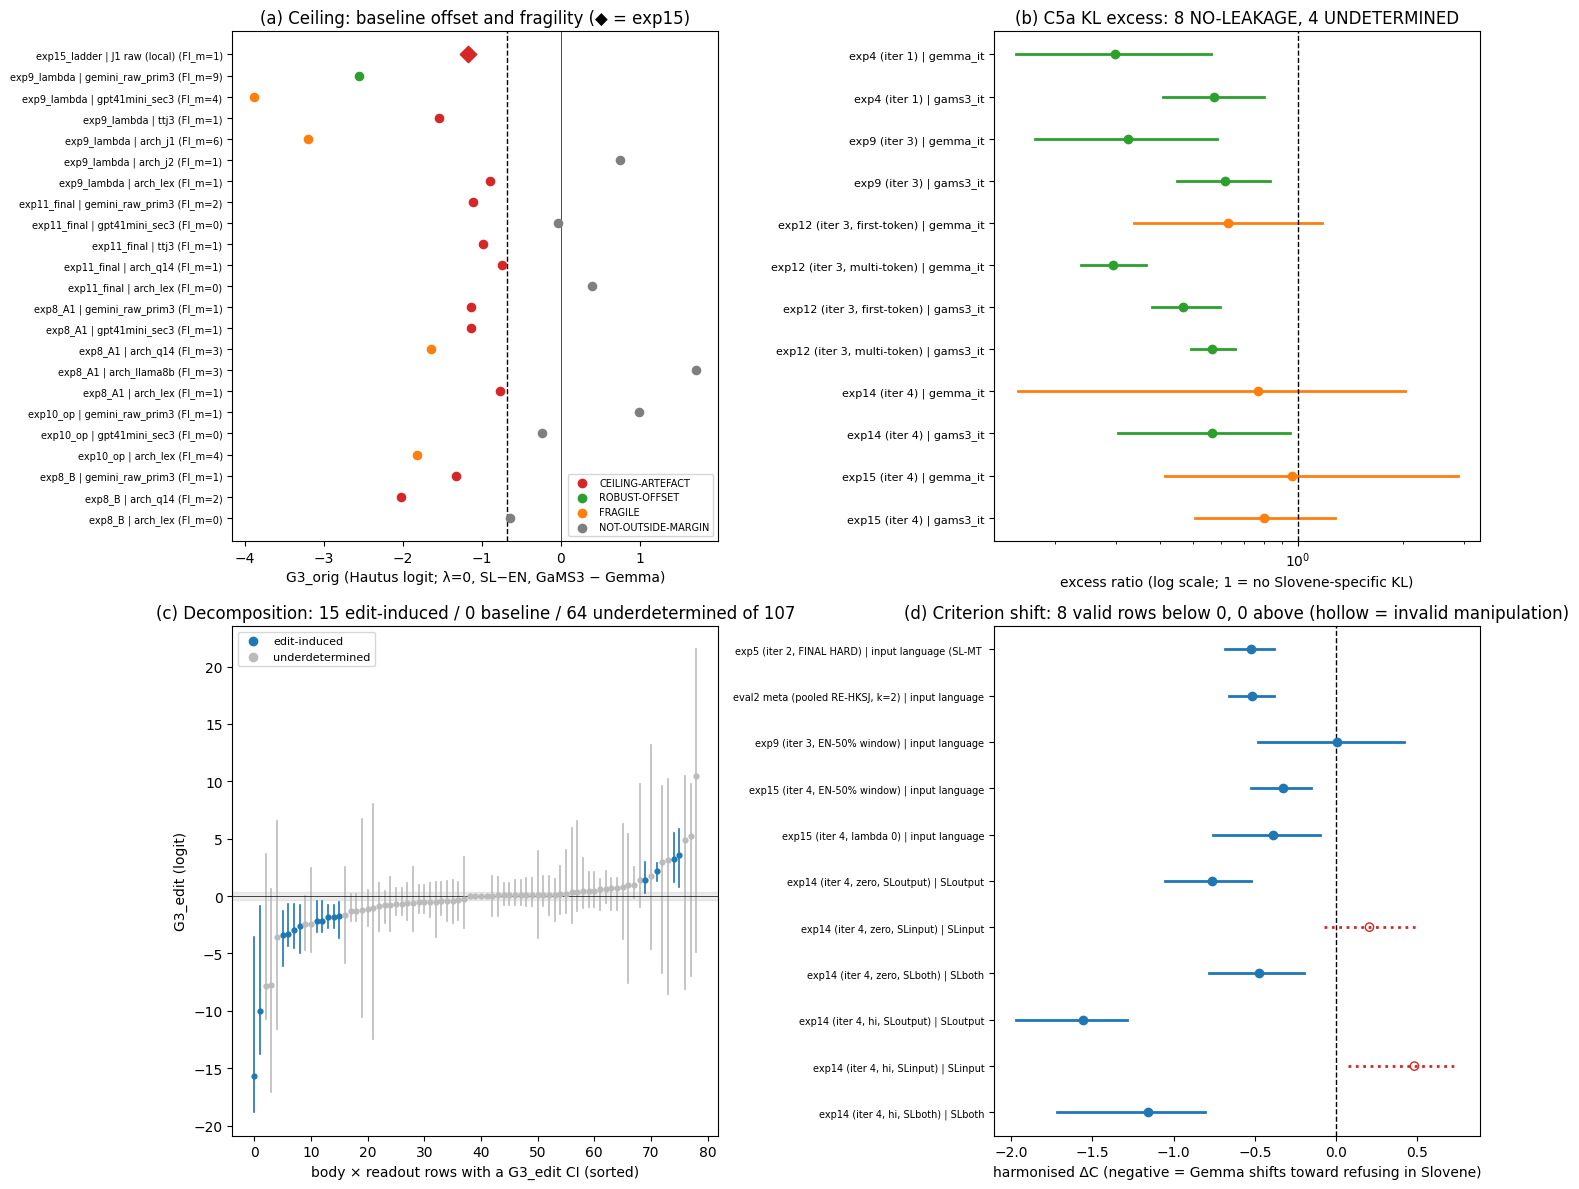

In [10]:
# ---- 1) exact reproduction of the saved headline metrics
ref = data["reference_metrics_agg"]
ma = eval_out["metrics_agg"]
diff = {k2: (ma.get(k2), ref[k2]) for k2 in ref if ma.get(k2) is None or abs(ma[k2] - ref[k2]) > 1e-12}
print(f"metrics_agg: {len(ma)} recomputed vs {len(ref)} saved -> {len(ref) - len(diff)} identical, {len(diff)} differ")
for k2, (a2, b2) in diff.items():
    print(f"   DIFF {k2}: recomputed {a2} vs saved {b2}")
print("example counts (demo vs saved full run):",
      {dd["dataset"]: (len(dd["examples"]), data["reference_dataset_sizes"][dd["dataset"]]) for dd in eval_out["datasets"]})
print("(the ledger example list is smaller because the demo data holds a 56-row stratified sample of the 1,176 tokens)\n")

# ---- 2) headline table
groups = {
    "(1) CEILING - exp15 G3_orig": ["exp15_G3_orig", "exp15_FI_m", "exp15_FI_0", "exp15_prob_did_pp", "exp15_prob_did_pp_ci95_lo",
                                    "exp15_prob_did_pp_ci95_hi", "exp15_jeffreys_P_G3orig_lt_minus_m", "exp15_model_perm_p",
                                    "exp15_expected_mislabels_4cells", "exp15_ceiling_artefact"],
    "(2) C5a KL excess": ["kl_exp15_gemma_excess", "kl_exp15_gams_excess", "kl_exp14_gemma_excess", "kl_exp14_gemma_ci95_lo",
                          "kl_exp14_gemma_ci95_hi", "kl_exp9_gemma_excess", "kl_exp9_gams_excess", "kl_rows_no_leakage",
                          "kl_rows_undetermined", "kl_gpu_gate_pass"],
    "(3) DECOMPOSITION": ["decomp_rows", "decomp_edit_induced", "decomp_baseline", "decomp_underdetermined"],
    "(4) exp14 TABLES + LEDGER": ["exp14_crosscheck_mismatches", "exp14_paper_tables_28_29_values_compared",
                                  "exp14_paper_tables_28_29_values_differ", "ledger_tokens", "ledger_pointers", "ledger_survives",
                                  "ledger_untraceable", "ledger_claim_level_reversals", "ledger_attribution_errors",
                                  "ledger_placebo_auto_match_rate"],
    "(5) CRITERION SHIFT + exp13": ["crit_rows_total", "crit_rows_invalid_manipulation", "crit_valid_rows_ci_below_0",
                                    "crit_valid_rows_ci_above_0", "exp13_B_overlap", "exp13_C_overlap", "exp13_never_generated"],
    "VERIFY / COST": ["verify_n_checks", "verify_pass_rate", "openrouter_spend_usd"],
}
for g, keys in groups.items():
    print(g)
    for k2 in keys:
        v2 = ma[k2]
        print(f"   {k2:<45s} {v2:>10.4g}")
res = data["results"]
print("\nFrozen-rule verdict sentences:")
print("  ceiling :", res["ceiling_sensitivity.json"]["paper_sentence"])
print("  C5a     :", res["kl_excess.json"]["reconciliation"]["sentence"])
print("  crit    :", res["step6.json"]["criterion_shift"]["compliance_valid_sentence"])

# ---- 3) figure
m = res["ceiling_sensitivity.json"]["m"]
vcol = {"CEILING-ARTEFACT": "#d62728", "ROBUST-OFFSET": "#2ca02c", "FRAGILE": "#ff7f0e", "NOT-OUTSIDE-MARGIN": "#7f7f7f",
        "NO-LEAKAGE": "#2ca02c", "UNDETERMINED": "#ff7f0e", "LEAKAGE": "#d62728", "POINT-ONLY": "#7f7f7f",
        "edit-induced": "#1f77b4", "underdetermined": "#bbbbbb", "baseline": "#9467bd"}
fig, ax = plt.subplots(2, 2, figsize=(15, 12))

# (a) ceiling
ce = [e for e in eval_out["datasets"][1]["examples"]]
ya = np.arange(len(ce))
for i, e in enumerate(ce):
    ax[0, 0].scatter(e["eval_G3_orig"], i, color=vcol[e["metadata_verdict"]], s=70 if i == 0 else 35,
                     marker="D" if i == 0 else "o", zorder=3)
ax[0, 0].set_yticks(ya, [f"{e['metadata_body']} | {e['metadata_label']} (FI_m={e['eval_FI_m']:.0f})" for e in ce], fontsize=7)
ax[0, 0].axvline(-m, ls="--", c="k", lw=1); ax[0, 0].axvline(0, c="k", lw=0.5)
ax[0, 0].invert_yaxis(); ax[0, 0].set_xlabel("G3_orig (Hautus logit; λ=0, SL−EN, GaMS3 − Gemma)")
ax[0, 0].set_title("(a) Ceiling: baseline offset and fragility (◆ = exp15)")
for lab in ("CEILING-ARTEFACT", "ROBUST-OFFSET", "FRAGILE", "NOT-OUTSIDE-MARGIN"):
    ax[0, 0].scatter([], [], color=vcol[lab], label=lab)
ax[0, 0].legend(fontsize=7, loc="lower right")

# (b) KL excess
kl = eval_out["datasets"][2]["examples"]
for i, e in enumerate(kl):
    lo, hi = e["eval_ci95_lo"], e["eval_ci95_hi"]
    ax[0, 1].plot([lo, hi], [i, i], c=vcol[e["metadata_verdict"]], lw=2)
    ax[0, 1].scatter(e["eval_excess"], i, color=vcol[e["metadata_verdict"]], zorder=3)
kl_rows = [r for r in res["kl_excess.json"]["reconciliation"]["rows"] if "point" in r]  # same order as the examples
ax[0, 1].set_yticks(range(len(kl)), [f"{r['body']} | {r['model']}" for r in kl_rows], fontsize=8)
ax[0, 1].axvline(1, ls="--", c="k", lw=1); ax[0, 1].set_xscale("log"); ax[0, 1].invert_yaxis()
ax[0, 1].set_xlabel("excess ratio (log scale; 1 = no Slovene-specific KL)")
ax[0, 1].set_title(f"(b) C5a KL excess: {ma['kl_rows_no_leakage']:.0f} NO-LEAKAGE, {ma['kl_rows_undetermined']:.0f} UNDETERMINED")

# (c) decomposition: rows with a G3_edit CI
drows = [r for r in res["decomposition_table.json"]["rows"] if r.get("G3_edit", {}).get("ci95") and r["G3_edit"]["ci95"][0] is not None]
drows.sort(key=lambda r: r["G3_edit"]["point"])
for i, r in enumerate(drows):
    st = r.get("decomposition_status") or "underdetermined"
    lo, hi = r["G3_edit"]["ci95"]
    ax[1, 0].plot([i, i], [lo, hi], c=vcol.get(st, "#bbbbbb"), lw=1.2)
    ax[1, 0].scatter(i, r["G3_edit"]["point"], color=vcol.get(st, "#bbbbbb"), s=12, zorder=3)
ax[1, 0].axhspan(-m / 2, m / 2, color="k", alpha=0.07); ax[1, 0].axhline(0, c="k", lw=0.5)
ax[1, 0].set_xlabel("body × readout rows with a G3_edit CI (sorted)"); ax[1, 0].set_ylabel("G3_edit (logit)")
ax[1, 0].set_title(f"(c) Decomposition: {ma['decomp_edit_induced']:.0f} edit-induced / {ma['decomp_baseline']:.0f} baseline / "
                   f"{ma['decomp_underdetermined']:.0f} underdetermined of {ma['decomp_rows']:.0f}")
for lab in ("edit-induced", "underdetermined"):
    ax[1, 0].scatter([], [], color=vcol[lab], label=lab)
ax[1, 0].legend(fontsize=8)

# (d) criterion shift
cr = [r for r in res["step6.json"]["criterion_shift"]["rows"] if r.get("harmonised_ci95")]
for i, r in enumerate(cr):
    lo, hi = r["harmonised_ci95"]
    ok = r.get("manipulation_valid", True)
    col = "#1f77b4" if ok else "#d62728"
    ax[1, 1].plot([lo, hi], [i, i], c=col, lw=2, ls="-" if ok else ":")
    ax[1, 1].scatter(r["harmonised_value"], i, facecolors=col if ok else "none", edgecolors=col, zorder=3)
ax[1, 1].set_yticks(range(len(cr)), [f"{r['body'][:34]} | {r.get('output_language', '')[:22]}" for r in cr], fontsize=7)
ax[1, 1].axvline(0, ls="--", c="k", lw=1); ax[1, 1].invert_yaxis()
ax[1, 1].set_xlabel("harmonised ΔC (negative = Gemma shifts toward refusing in Slovene)")
ax[1, 1].set_title(f"(d) Criterion shift: {ma['crit_valid_rows_ci_below_0']:.0f} valid rows below 0, "
                   f"{ma['crit_valid_rows_ci_above_0']:.0f} above (hollow = invalid manipulation)")
plt.tight_layout()
plt.show()

## Reading the results

* **Ceiling (a).** exp15's `G3_orig = -1.171` rests on near-ceiling counts (294/299 and 289/292 of 300). One
  flipped Gemma-SL label moves it inside ±m (FI_m = 1), while about 16 judge mislabels are expected. Under the frozen
  rule this is a **CEILING-ARTEFACT**, so the baseline claim loses its exp15 support. Among the eval3 bodies, only
  exp9 under the paid Gemini readout is a **ROBUST-OFFSET** (FI_m = 9).
* **C5a (b).** No row shows LEAKAGE. The exp15 rows and the exp14/exp12 Gemma rows are **UNDETERMINED** (their
  CIs include 1), so "no Slovene leakage" holds only in some bodies.
* **Decomposition (c).** Most rows are underdetermined. The edit-induced rows split by sign (lag vs anti-lag), and
  no row qualifies as a pure baseline effect.
* **Criterion shift (d).** Among compliance-valid rows, 8 of 9 CIs lie below 0 and none above. The CI-positive
  exp14 SL-input rows are invalid manipulations (GaMS3 never complied with SL→EN). Applied to *all* rows, the frozen
  rule still gives "unresolved cross-body disagreement".

To run the **full** pipeline (Steps 0–7 with the complete ledger), use the artifact repository: set
`SKIP_STEPS = False` (CLI: `python eval.py` without `--skip-steps`) and point `AII_RUN_ROOT` at the upstream
artifacts.